<a href="https://colab.research.google.com/github/aswaroop976/AOC_2024/blob/main/Adversarial_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Fooling models with adversarial examples**

In this homework assignment, you will be crafting an adversarial attack to fool a simple machine learning model. The code for training the model is provided, so you will only be writing the code for a FGSM/PGD attack. After creating your attack, you will use it to measure the model prediction accuracy under several different attack parameters.

This assignment can be completed on Google Colab. Since there is some model training done, the free GPU can help speed up the process. To use one, you can click the down arrow in the top right of the page and select the "Change runtime type" option. From here, the T4 GPU can be selected. This is optional to do given the simplicity of the model, since the overall training will not take very long on the
 non-GPU version.

<br>

The PGD attack is formulated as:

$x_{adv}^{t+1}=\mathcal{P}(x_{adv}^{t}+\alpha*sign[∇_{x_{adv}^{t}}\mathcal{L(\theta,x_{adv}^{t},y)}])   \text{ where the attack is constrained by } ||x_{adv}-x|| \leq ɛ$.

<br>

The PGD attack is an iterative, multi-step attack. The attack is described below.

- For the initialization, $X_{adv}^0=x$ will be used.

- $\mathcal{L}(\theta,x_{adv}^t,y)$ refers to the loss of the model on the adversarial example $x_{adv}^{t}$. The attack will use the gradient of $x_{adv}^{t}$ with respect to this loss $∇_{x_{adv}^{t}}\mathcal{L(\theta,x_{adv}^{t},y)}$ to update the adversarial example.

- For each step in the attack, the $sign$ of the gradient will be used with a step of size $\alpha$ for the update. The step size $\alpha$ will vary based on the total number of steps used by the attack.

- After each step, a projection operation $\mathcal{P}$ is applied to ensure that each pixel of $x_{adv}^{t}$ is no more than $\varepsilon$ away from the original image $x$ (in practice, this can be done by clipping the image).

- The adversarial example will also be constrained to be within the bounds of a natural image [0, 1] (also through clipping).

<br>

The code below creates a simple CNN model and trains it on CIFAR-10 for 20 epochs. The code can be run without any modification.

100%|██████████| 170M/170M [00:04<00:00, 40.3MB/s]


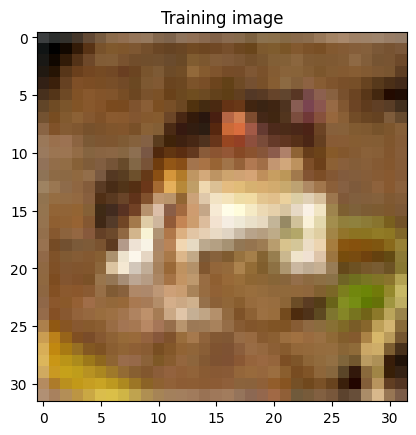

  0%|                                                                                                         …

  0%|                                                                                                         …

  0%|                                                                                                         …

  0%|                                                                                                         …

  0%|                                                                                                         …

...

  0%|                                                                                                         …

  0%|                                                                                                         …

  0%|                                                                                                         …

  0%|                                                                                                         …

  0%|                                                                                                         …

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as npiii

class CNN(nn.Module):
  def __init__(self, num_classes=10):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.fc1 = nn.Linear(64*4*4, 256)
    self.fc2 = nn.Linear(256, num_classes)
    self.pool = nn.MaxPool2d(2,2)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return(x)

transform = transforms.Compose([
  transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='data', train=True, transform=transform, download=True)
testset  = torchvision.datasets.CIFAR10(root='data', train=False, transform=transform)

trainloader = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=1, pin_memory=True)
testloader  = DataLoader(testset, batch_size=1000, shuffle=False, num_workers=1, pin_memory=True)

plt.imshow(trainset[0][0].permute(1,2,0))
plt.title('Training image')
plt.show()


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN(num_classes=10).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

from tqdm.notebook import tqdm

epochs = 20

for epoch in range(epochs):  # loop over the dataset multiple times

  total_correct_train, total_samples, total_loss, total_batches = 0, 0, 0, 0

  for X, Y in (pbar := tqdm(trainloader, ncols=1000)):
    X, Y = X.to(device), Y.to(device)

    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, Y)

    total_loss += loss.item()
    total_batches += 1
    total_correct_train += (pred.argmax(dim=1) == Y).sum()
    total_samples += X.shape[0]

    average_loss = total_loss/total_batches
    train_acc = total_correct_train*100/total_samples

    pbar.set_description(f"{epoch+1}/{epochs}   {average_loss=:.04e}  {train_acc=:.02f}%")

    loss.backward()
    optimizer.step()

  total_correct, total_samples, test_acc = 0, 0, 0

  for X, Y in (pbar := tqdm(testloader, ncols=1000)):
    X, Y = X.to(device), Y.to(device)
    total_samples += X.shape[0]

    with torch.no_grad(): pred = model(X)
    total_correct += (pred.argmax(dim=1) == Y).sum()

    test_acc = total_correct*100/total_samples

    pbar.set_description(f"{epoch+1}/{epochs}   {test_acc=:.02f}%")




## **Creating an adversarial attack**

Below you will find a basic template for creating the adversarial attack. Please fill out the below function where indicated.

<br>

***Details:***

We will vary the step size based on the number of steps. Recall that it is okay for any step to go beyond the boundary of $ɛ$, since it will be projected back to the $ɛ$ boundary.

- If the number of steps $= 1$, $\alpha = ɛ$
- If the number of steps $>1$ but $<4$, $\alpha = \frac{ɛ}{\text{num_steps}-1}$
- If the number of steps $\geq 4$, $\alpha = \frac{eps}{4}$

For the adversarial example generation, you will need to implement a few parts. Please look at the code for individual hints. For each step in the attack, you will need to:

- Compute the loss on the X_adv
- Compute the gradient of X_adv using this loss
- Update the X_adv using the sign of the gradient
- Clip the difference between X and X_adv to be $\leqɛ$
- Clip X_adv to being between [0, 1]

<br>

***Verification***

The code at the bottom evaluates the model on your PGD attack with $\varepsilon=\frac{8}{255}$ and 10 steps. If the implementation is correct, the accuracy of the model against the attack should be very low (around 5% or less).

In [10]:
def pgd(model=None, X=None, Y=None, eps:float=8./255, num_steps=10):
  """
  this pgd assumes the data passed to it is in the range of [0,1]
  """

  # Here we define the loss used. Since we are working with a classification
  # task, we will use the CrossEntropyLoss.
  loss = nn.CrossEntropyLoss()

  # First create a copy of the original training data. Requires_grad is set to
  # True, since the gradient of the image will need to be computed.
  X_adv = X.clone().detach().requires_grad_(True)
  X_orig = X.clone().detach() # Keep original X for clamping the perturbation

  # The model parameter gradient computation is turned off for the optimization
  # since we will not need it.
  requires_grad_list = []
  for p in model.parameters():
    requires_grad_list.append(p.requires_grad)
    p.requires_grad_(False)

  # ------------------------ [FILL IN CODE HERE] ------------------------------

  # The step size of the attack is chosen based on the number of steps taken.
  # ---- Fill this in ---- #
  if num_steps == 1:
    alpha = eps
  elif num_steps > 1 and num_steps < 4:
    alpha = eps / (num_steps - 1)
  elif num_steps >= 4:
    alpha = eps/4

  # Here, is the main part of the adversarial attack.
  # ---- Fill this in ---- #
  for _ in range(num_steps):
    # Zero out previous gradients on X_adv
    if X_adv.grad is not None:
        X_adv.grad.zero_()

    # Calculate the loss on the current adversarial example.
    # Hint, use the "loss" we defined before.
    # ---- Fill this in ---- #
    outputs = model(X_adv)
    cost = loss(outputs, Y)

    # Compute the gradient on the adversarial image using the previous output
    # of the loss. Hint, use the .backward() operation in PyTorch.
    # ---- Fill this in ---- #
    cost.backward()

    with torch.no_grad():
      # Update the adversarial example by taking a step in the direction of the
      # sign of the gradient of the image X_adv. Use the step_size you defined
      # previously.
      # Perform in-place update to maintain requires_grad=True
      # ---- Fill this in ---- #
      X_adv.data += alpha * X_adv.grad.sign()

      # Clip the difference between X and X_adv to be within eps of each other.
      # Hint, use torch.clamp()
      # Calculate the perturbation from the original image
      # ---- Fill this in ---- #
      delta = X_adv.data - X_orig
      # Clamp the perturbation to be within [-eps, eps]
      delta.clamp_(-eps, eps) # In-place clamp
      # Apply the clamped perturbation to the original image to get the new X_adv
      X_adv.data = X_orig + delta

      # Clip the adversarial image to be between [0, 1].
      # ---- Fill this in ---- #
      X_adv.data.clamp_(0, 1) # In-place clamp
  # ---------------------------------------------------------------------------
  X_adv.requires_grad_(True)
  # Reset the model
  for p, b in zip(model.parameters(), requires_grad_list):
    p.grad = None
    p.requires_grad_(b)

  # reset model state
  X_adv.requires_grad_(False)
  return X_adv.detach()


def evaluate_adv(model=None, testloader=None, eps=(8/255.), num_steps=10):
  '''
  This function evaluates the model using the attack parameters provided. The
  accuracy against the adversarial attack is returned along with the total
  correct and wrong prediction. No modification is necessary.
  '''
  total_samples, adv_correct, adv_acc = 0, 0, 0

  for X, Y in iter(testloader):
    X, Y = X.to(device), Y.to(device)
    total_samples += X.shape[0]

    if eps != 0:
      X_adv = pgd(model, X, Y, eps, num_steps)
    else:
      X_adv = X

    with torch.no_grad(): pred = model(X_adv)
    adv_correct += (pred.argmax(dim=1) == Y).sum()
    adv_acc = adv_correct*100/total_samples

  return adv_acc, adv_correct, total_samples-adv_correct


adv_acc, correct, wrong = evaluate_adv(model, testloader, eps=(8/255.), num_steps=10)

print("Correct: %i  \nWrong: %i \nTotal:  %i  \nThe adversarial accuracy is: %.2f  " % (correct.item(), wrong.item(), correct.item()+wrong.item(),  adv_acc.item()))

Correct: 47  
Wrong: 9953 
Total:  10000  
The adversarial accuracy is: 0.47  


## **Experimenting with the attack**

Now that the attack is implemented, let's experiment with it. Run the attack with some different hyperparameters and report the results. Suggestions for the values are given, but feel free to experiment with other values. Matplotlib can be used to plot the results.

- Plot the model accuracy when varying $\varepsilon$ ($\frac{0}{255} - \frac{16}{255}$) while keeping the number of steps fixed at 10.

- Plot the model accuracy when varying the number of attack steps (1 - 10) while keeping the epsilon fixed at 8/255.

- Plot images with different $\varepsilon$ ($\frac{0}{255} - \frac{30}{255}$, plotting every other value). Keep the number of steps fixed at 10.

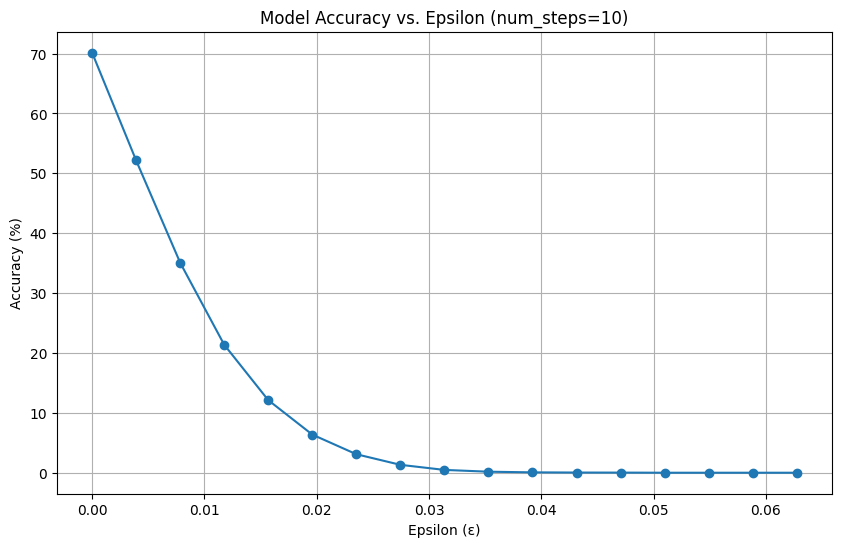

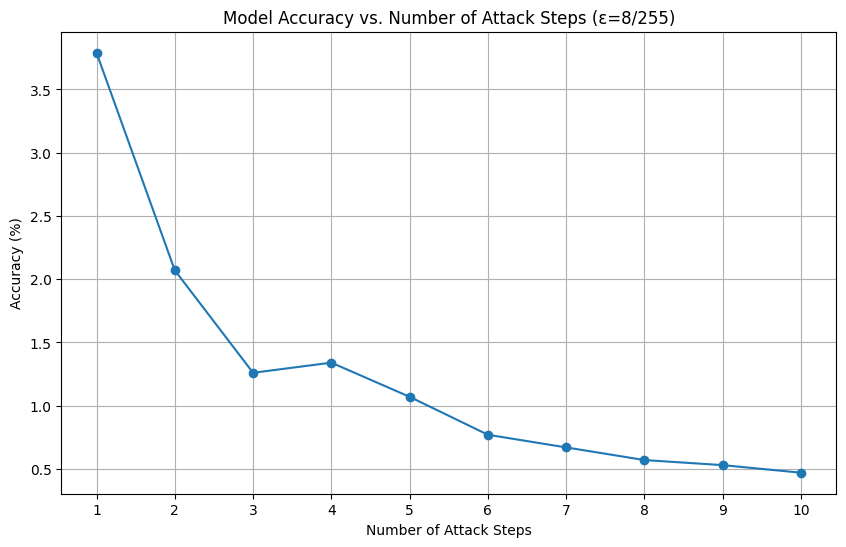

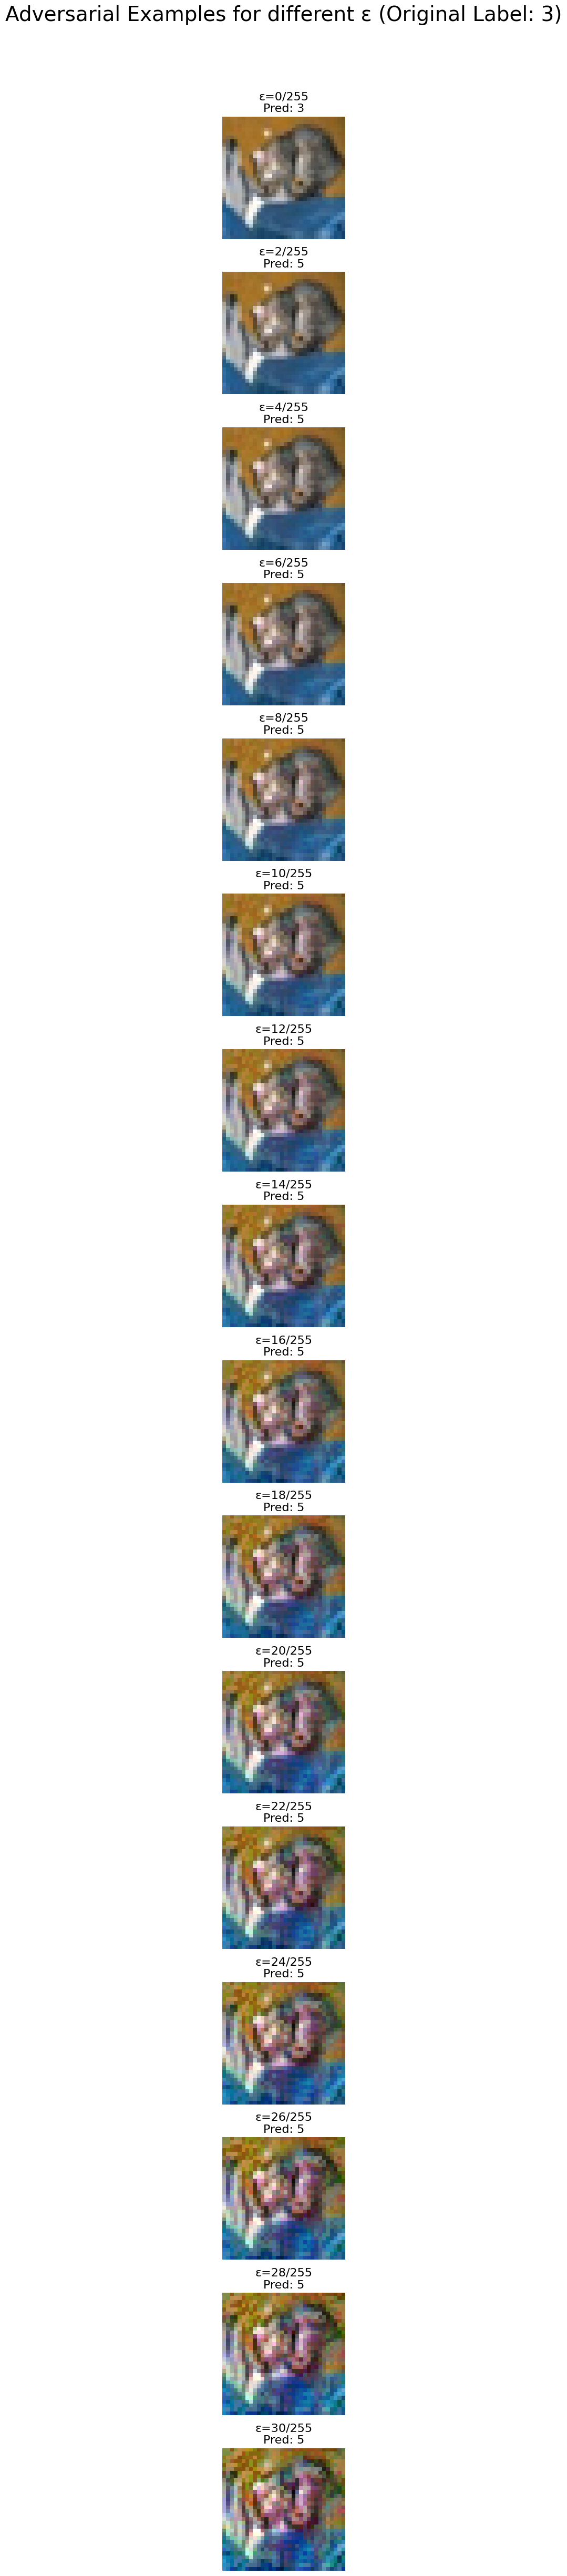

In [12]:
import matplotlib.pyplot as plt
import numpy as npiii

# Plot the model accuracy when varying epsilon
eps_values = [i / 255. for i in range(0, 17, 1)] # 0/255 to 16/255
accuracies_eps = []

for eps in eps_values:
    adv_acc, _, _ = evaluate_adv(model, testloader, eps=eps, num_steps=10)
    accuracies_eps.append(adv_acc.item())

plt.figure(figsize=(10, 6))
plt.plot(eps_values, accuracies_eps, marker='o')
plt.title('Model Accuracy vs. Epsilon (num_steps=10)')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

# Plot the model accuracy when varying the number of attack steps
step_values = list(range(1, 11)) # 1 to 10 steps
accuracies_steps = []

for steps in step_values:
    adv_acc, _, _ = evaluate_adv(model, testloader, eps=8./255, num_steps=steps)
    accuracies_steps.append(adv_acc.item())

plt.figure(figsize=(10, 6))
plt.plot(step_values, accuracies_steps, marker='o')
plt.title('Model Accuracy vs. Number of Attack Steps (ε=8/255)')
plt.xlabel('Number of Attack Steps')
plt.ylabel('Accuracy (%)')
plt.xticks(step_values)
plt.grid(True)
plt.show()

# Plot images with different epsilon values
eps_plot_values = [i / 255. for i in range(0, 31, 2)] # 0/255 to 30/255, every other value
num_images_to_plot = len(eps_plot_values)

# Get one original image and its label from the test set
original_image, original_label = testset[0]
original_image = original_image.unsqueeze(0).to(device) # Add batch dimension and move to device
original_label = torch.tensor([original_label]).to(device)

# Adjusted figsize for vertical arrangement and smaller images
plt.figure(figsize=(5, num_images_to_plot * 3)) # Reduced width, increased height for vertical stacking

for i, eps in enumerate(eps_plot_values):
    if eps == 0:
        adv_image = original_image
    else:
        adv_image = pgd(model, original_image, original_label, eps=eps, num_steps=10)

    # Move image to CPU and convert to numpy for plotting
    adv_image_np = adv_image.squeeze(0).permute(1, 2, 0).cpu().numpy()

    # Get model prediction for the adversarial image
    with torch.no_grad():
        pred = model(adv_image)
        predicted_label = pred.argmax(dim=1).item()

    plt.subplot(num_images_to_plot, 1, i + 1) # Changed to vertical subplot arrangement
    plt.imshow(adv_image_np)
    plt.title(f'ε={eps*255:.0f}/255\nPred: {predicted_label}', fontsize=16) # Increased subplot title font size
    plt.axis('off')

plt.suptitle(f'Adversarial Examples for different ε (Original Label: {original_label.item()})', y=1.02, fontsize=28) # Further increased suptitle font size
plt.tight_layout()
plt.show()